In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
# CELL 1: Data Load
train_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
print("Data loaded! Rows:", train_df.shape[0])
train_df.head()

Data loaded! Rows: 1460


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# CELL 2: Features select cheyadam
df = train_df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']].dropna()
print("Cleaned Data Shape:", df.shape)
df.head()

Cleaned Data Shape: (1460, 4)


,GrLivArea,BedroomAbvGr,FullBath,SalePrice
0,1710,3,2,208500
1,1262,3,2,181500
2,1786,3,2,223500
3,1717,3,1,140000
4,2198,4,2,250000


In [4]:
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']] 
y = df['SalePrice']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 3)
y shape: (1460,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (1168, 3)  Test: (292, 3)


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model Trained")

Model Trained


In [7]:
y_pred = model.predict(X_test)
print("Predictions done")

Predictions done


In [8]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2 Score:", r2)

MSE: 2806426667.247853
R2 Score: 0.6341189942328371


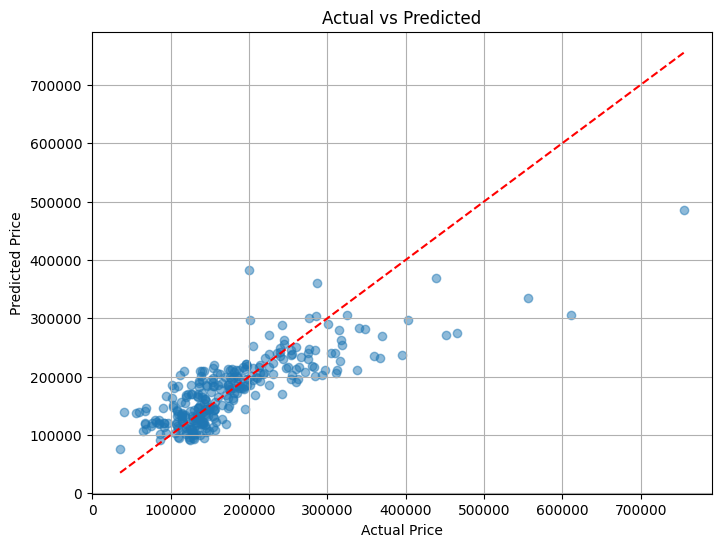

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

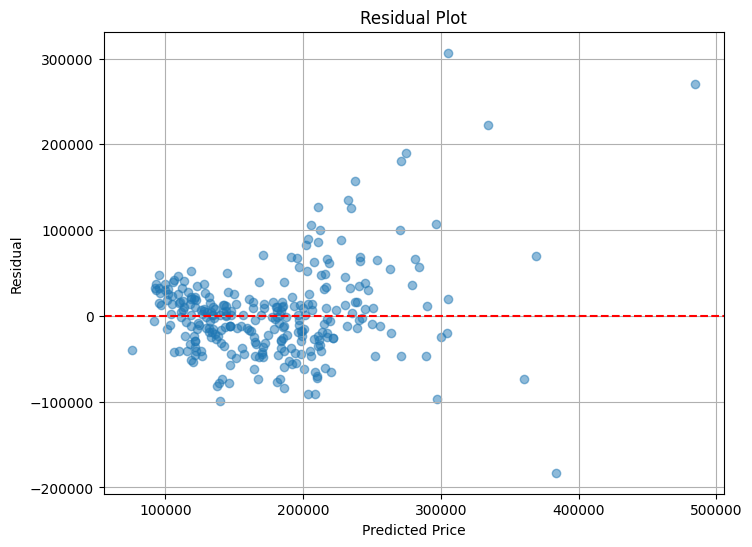

In [10]:
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [11]:
metrics_df = pd.DataFrame({'Metric': ['MSE', 'R2 Score'], 'Value': [mse, r2]})
metrics_df.to_csv('model_metrics.csv', index=False)
print("model_metrics.csv created!")
print(metrics_df)

model_metrics.csv created!
     Metric         Value
0       MSE  2.806427e+09
1  R2 Score  6.341190e-01
